# 1. Install + Setup

In [ ]:
!pip install torch transformers matplotlib

In [ ]:
import time, math
from dataclasses import dataclass
from typing import Dict, List

import torch
from transformers import LlamaConfig, LlamaForCausalLM
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4


# 2. KV cache sizing helpers

In [ ]:
DTYPE_BYTES = {
    torch.float32: 4,
    torch.float16: 2,
    torch.bfloat16: 2,
    torch.int8: 1,
}

def sizeof_past_key_values(past_key_values) -> int:
    if past_key_values is None:
        return 0

    # If transformers returns a Cache object, convert to legacy tuple format if possible
    if hasattr(past_key_values, "to_legacy_cache"):
        past_key_values = past_key_values.to_legacy_cache()

    total = 0

    # Expected legacy format: tuple(num_layers) of tuples (k, v)
    for layer_kv in past_key_values:
        if layer_kv is None:
            continue

        # layer_kv might be (k, v) or something similar
        if isinstance(layer_kv, (tuple, list)):
            for t in layer_kv:
                if t is None:
                    continue
                total += t.numel() * t.element_size()
        else:
            # Unexpected single tensor (rare), handle anyway
            t = layer_kv
            if t is not None and hasattr(t, "numel"):
                total += t.numel() * t.element_size()

    return total

def analytical_kv_bytes(
    num_layers: int,
    batch_size: int,
    seq_len: int,
    num_kv_heads: int,
    head_dim: int,
    dtype: torch.dtype,
) -> int:
    bytes_per = DTYPE_BYTES.get(dtype, torch.tensor([], dtype=dtype).element_size())
    return 2 * num_layers * batch_size * seq_len * num_kv_heads * head_dim * bytes_per  # 2 for K+V

def bytes_to_gb(nbytes: int) -> float:
    return nbytes / (1024**3)

def gpu_mem_gb():
    if not torch.cuda.is_available():
        return None
    alloc = torch.cuda.memory_allocated() / (1024**3)
    reserv = torch.cuda.memory_reserved() / (1024**3)
    return alloc, reserv

# 3. Build model configs for MHA vs GQA

In [ ]:
@dataclass
class SimConfig:
    hidden_size: int = 1024
    num_layers: int = 16
    num_heads: int = 16
    num_kv_heads: int = 16  # MHA: = num_heads, GQA: smaller

    vocab_size: int = 32000
    max_position_embeddings: int = 16384

    batch_size: int = 1
    total_tokens: int = 4096
    prompt_tokens: int = 128
    measure_every: int = 256

    dtype: torch.dtype = torch.float16
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

def build_llama_model(cfg: SimConfig) -> LlamaForCausalLM:
    assert cfg.hidden_size % cfg.num_heads == 0

    llama_cfg = LlamaConfig(
        vocab_size=cfg.vocab_size,
        hidden_size=cfg.hidden_size,
        intermediate_size=4 * cfg.hidden_size,
        num_hidden_layers=cfg.num_layers,
        num_attention_heads=cfg.num_heads,
        num_key_value_heads=cfg.num_kv_heads,
        max_position_embeddings=cfg.max_position_embeddings,
        rms_norm_eps=1e-5,
        rope_theta=10000.0,
        attention_bias=False,
        # This keeps cache format stable across transformer versions/backends
        attn_implementation="eager",
    )

    model = LlamaForCausalLM(llama_cfg).to(cfg.device).eval()
    model = model.to(dtype=cfg.dtype)
    return model

# 4. Simulation: token-by-token KV growth

In [ ]:
@torch.no_grad()
def run_kv_growth(cfg: SimConfig) -> Dict[str, List]:
    model = build_llama_model(cfg)
    head_dim = cfg.hidden_size // cfg.num_heads

    # synthetic prompt
    prompt_ids = torch.randint(
        0, cfg.vocab_size, (cfg.batch_size, cfg.prompt_tokens), device=cfg.device
    )

    # Prefill
    t0 = time.time()
    out = model(input_ids=prompt_ids, use_cache=True)
    past = out.past_key_values
    prefill_ms = (time.time() - t0) * 1000

    results = {
        "seq_len": [],
        "kv_gb_empirical": [],
        "kv_gb_analytical": [],
        "step_time_ms": [],
        "gpu_alloc_gb": [],
        "gpu_reserved_gb": [],
    }

    def record(seq_len: int, step_ms: float):
        emp = sizeof_past_key_values(past)
        ana = analytical_kv_bytes(
            num_layers=cfg.num_layers,
            batch_size=cfg.batch_size,
            seq_len=seq_len,
            num_kv_heads=cfg.num_kv_heads,
            head_dim=head_dim,
            dtype=cfg.dtype,
        )
        results["seq_len"].append(seq_len)
        results["kv_gb_empirical"].append(bytes_to_gb(emp))
        results["kv_gb_analytical"].append(bytes_to_gb(ana))
        results["step_time_ms"].append(step_ms)

        gm = gpu_mem_gb()
        if gm is None:
            results["gpu_alloc_gb"].append(None)
            results["gpu_reserved_gb"].append(None)
        else:
            results["gpu_alloc_gb"].append(gm[0])
            results["gpu_reserved_gb"].append(gm[1])

    record(cfg.prompt_tokens, prefill_ms)

    # Generate one token at a time
    current_len = cfg.prompt_tokens
    next_token = torch.randint(0, cfg.vocab_size, (cfg.batch_size, 1), device=cfg.device)

    for _ in range(cfg.prompt_tokens, cfg.total_tokens):
        t1 = time.time()
        out = model(input_ids=next_token, past_key_values=past, use_cache=True)
        past = out.past_key_values
        dt_ms = (time.time() - t1) * 1000

        next_token = torch.randint(0, cfg.vocab_size, (cfg.batch_size, 1), device=cfg.device)
        current_len += 1

        if (current_len % cfg.measure_every) == 0 or current_len == cfg.total_tokens:
            record(current_len, dt_ms)

    # cleanup
    del model
    torch.cuda.empty_cache()
    return results

# 5. Run MHA vs GQA

Running MHA...
Running GQA...

=== MHA ===
layers=16 heads=16 kv_heads=16 hidden=1024 dtype=torch.float16
Last rows:
  seq=  2816  KV_emp=0.171875 GB  KV_ana=0.171875 GB  step=  18.74 ms  gpu_alloc=2.0774030685424805  gpu_res=2.6484375
  seq=  3072  KV_emp=0.187500 GB  KV_ana=0.187500 GB  step=  18.55 ms  gpu_alloc=2.0930280685424805  gpu_res=2.6484375
  seq=  3328  KV_emp=0.203125 GB  KV_ana=0.203125 GB  step=  18.54 ms  gpu_alloc=2.1086530685424805  gpu_res=2.6484375
  seq=  3584  KV_emp=0.218750 GB  KV_ana=0.218750 GB  step=  18.25 ms  gpu_alloc=2.1252546310424805  gpu_res=2.6484375
  seq=  3840  KV_emp=0.234375 GB  KV_ana=0.234375 GB  step=  23.54 ms  gpu_alloc=2.1540632247924805  gpu_res=2.6484375
  seq=  4096  KV_emp=0.250000 GB  KV_ana=0.250000 GB  step=  18.06 ms  gpu_alloc=2.1555280685424805  gpu_res=2.6484375

=== GQA ===
layers=16 heads=16 kv_heads=4 hidden=1024 dtype=torch.float16
Last rows:
  seq=  2816  KV_emp=0.042969 GB  KV_ana=0.042969 GB  step=  22.34 ms  gpu_alloc=1.

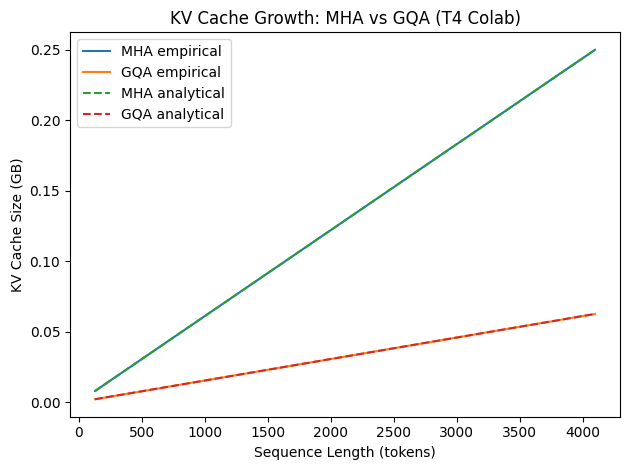


Final KV empirical:
  MHA: 0.250000 GB
  GQA: 0.062500 GB
  Reduction factor: 4.00x (expected ~4.00x)


In [ ]:
# Use sizes that are safe on a Colab T4.
# You can raise total_tokens to 8192 if it fits.
base = SimConfig(
    hidden_size=1024,
    num_layers=16,
    num_heads=16,
    batch_size=1,
    prompt_tokens=128,
    total_tokens=4096,
    measure_every=256,
    dtype=torch.float16,
)

cfg_mha = SimConfig(**{**base.__dict__, "num_kv_heads": base.num_heads})  # MHA
cfg_gqa = SimConfig(**{**base.__dict__, "num_kv_heads": 4})              # GQA example

print("Running MHA...")
res_mha = run_kv_growth(cfg_mha)

print("Running GQA...")
res_gqa = run_kv_growth(cfg_gqa)

def print_tail(name, cfg, res, k=6):
    print(f"\n=== {name} ===")
    print(f"layers={cfg.num_layers} heads={cfg.num_heads} kv_heads={cfg.num_kv_heads} hidden={cfg.hidden_size} dtype={cfg.dtype}")
    print("Last rows:")
    for i in range(max(0, len(res["seq_len"]) - k), len(res["seq_len"])):
        s = res["seq_len"][i]
        e = res["kv_gb_empirical"][i]
        a = res["kv_gb_analytical"][i]
        ms = res["step_time_ms"][i]
        ga = res["gpu_alloc_gb"][i]
        gr = res["gpu_reserved_gb"][i]
        print(f"  seq={s:6d}  KV_emp={e:.6f} GB  KV_ana={a:.6f} GB  step={ms:7.2f} ms  gpu_alloc={ga}  gpu_res={gr}")

print_tail("MHA", cfg_mha, res_mha)
print_tail("GQA", cfg_gqa, res_gqa)

# Plot KV growth
plt.figure()
plt.plot(res_mha["seq_len"], res_mha["kv_gb_empirical"], label="MHA empirical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_empirical"], label="GQA empirical")
plt.plot(res_mha["seq_len"], res_mha["kv_gb_analytical"], linestyle="--", label="MHA analytical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_analytical"], linestyle="--", label="GQA analytical")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth: MHA vs GQA (T4 Colab)")
plt.legend()
plt.tight_layout()
plt.show()

# Print reduction at final point
final_mha = res_mha["kv_gb_empirical"][-1]
final_gqa = res_gqa["kv_gb_empirical"][-1]
print("\nFinal KV empirical:")
print(f"  MHA: {final_mha:.6f} GB")
print(f"  GQA: {final_gqa:.6f} GB")
print(f"  Reduction factor: {final_mha / max(final_gqa, 1e-12):.2f}x (expected ~{cfg_mha.num_heads/cfg_gqa.num_kv_heads:.2f}x)")

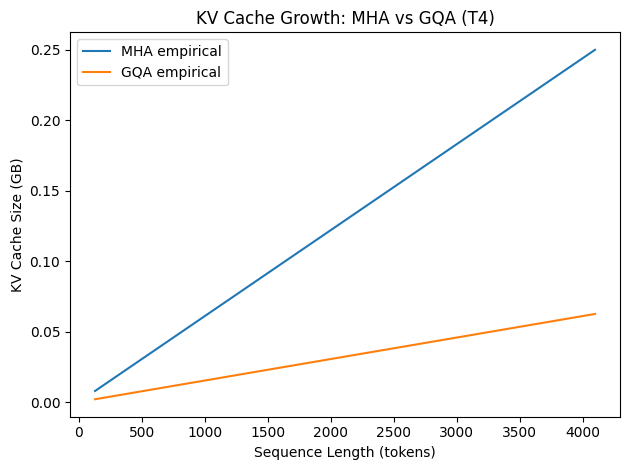

In [ ]:
plt.figure()
plt.plot(res_mha["seq_len"], res_mha["kv_gb_empirical"], label="MHA empirical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_empirical"], label="GQA empirical")
# plt.plot(res_mha["seq_len"], res_mha["kv_gb_analytical"], linestyle="--", label="MHA analytical")
# plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_analytical"], linestyle="--", label="GQA analytical")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth: MHA vs GQA (T4)")
plt.legend()
plt.tight_layout()
plt.show()

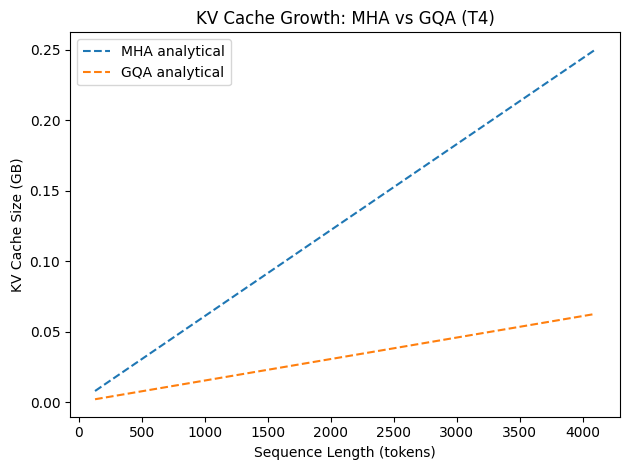

In [ ]:
plt.figure()
# plt.plot(res_mha["seq_len"], res_mha["kv_gb_empirical"], label="MHA empirical")
# plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_empirical"], label="GQA empirical")
plt.plot(res_mha["seq_len"], res_mha["kv_gb_analytical"], linestyle="--", label="MHA analytical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_analytical"], linestyle="--", label="GQA analytical")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth: MHA vs GQA (T4)")
plt.legend()
plt.tight_layout()
plt.show()


Running kv_heads=16 ...

Running kv_heads=8 ...

Running kv_heads=4 ...

Running kv_heads=2 ...

Running kv_heads=1 ...


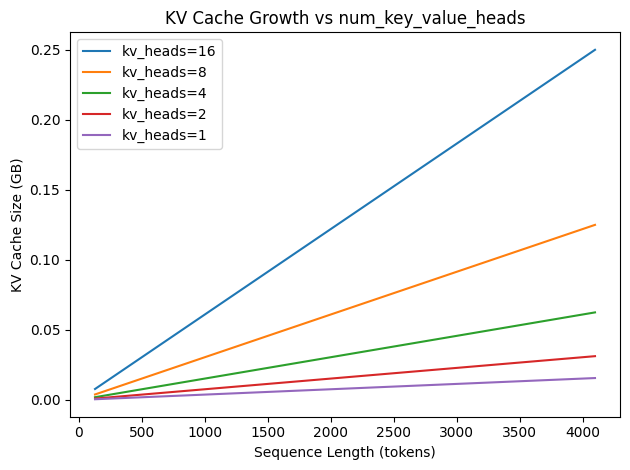


Final KV empirical at seq_len = 4096
  kv_heads=16: 0.250000 GB
  kv_heads= 8: 0.125000 GB
  kv_heads= 4: 0.062500 GB
  kv_heads= 2: 0.031250 GB
  kv_heads= 1: 0.015625 GB


In [ ]:
kv_heads_list = [16, 8, 4, 2, 1]  # MHA -> GQA -> MQA
sweep_results = {}

for kvh in kv_heads_list:
    cfg = SimConfig(**{**base.__dict__, "num_kv_heads": kvh})
    print(f"\nRunning kv_heads={kvh} ...")
    sweep_results[kvh] = run_kv_growth(cfg)

plt.figure()
for kvh in kv_heads_list:
    res = sweep_results[kvh]
    plt.plot(res["seq_len"], res["kv_gb_empirical"], label=f"kv_heads={kvh}")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth vs num_key_value_heads")
plt.legend()
plt.tight_layout()
plt.show()

# Show final KV per kv_heads
print("\nFinal KV empirical at seq_len =", base.total_tokens)
for kvh in kv_heads_list:
    res = sweep_results[kvh]
    print(f"  kv_heads={kvh:2d}: {res['kv_gb_empirical'][-1]:.6f} GB")

# 6. Above Experiments for Pre-Trained Model (Tiny Llama)

## Install + Imports

In [ ]:
!pip -q install transformers accelerate matplotlib sentencepiece

In [ ]:
import time
from dataclasses import dataclass
from typing import Dict, List, Optional

import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4


## KV sizing helpers

In [ ]:
DTYPE_BYTES = {
    torch.float32: 4,
    torch.float16: 2,
    torch.bfloat16: 2,
    torch.int8: 1,
}

def bytes_to_gb(nbytes: int) -> float:
    return nbytes / (1024**3)

def gpu_mem_gb():
    if not torch.cuda.is_available():
        return None
    alloc = torch.cuda.memory_allocated() / (1024**3)
    reserv = torch.cuda.memory_reserved() / (1024**3)
    return alloc, reserv

def sizeof_past_key_values(past_key_values) -> int:
    """
    Robust empirical KV bytes for HF caches:
      - legacy tuple-of-(k,v) per layer
      - Cache objects with .to_legacy_cache()
      - tolerates None entries
    """
    if past_key_values is None:
        return 0
    if hasattr(past_key_values, "to_legacy_cache"):
        past_key_values = past_key_values.to_legacy_cache()

    total = 0
    for layer_kv in past_key_values:
        if layer_kv is None:
            continue
        if isinstance(layer_kv, (tuple, list)):
            for t in layer_kv:
                if t is None:
                    continue
                total += t.numel() * t.element_size()
        else:
            t = layer_kv
            if t is not None and hasattr(t, "numel"):
                total += t.numel() * t.element_size()
    return total

def analytical_kv_bytes(
    num_layers: int,
    batch_size: int,
    seq_len: int,
    num_kv_heads: int,
    head_dim: int,
    dtype: torch.dtype,
) -> int:
    bytes_per = DTYPE_BYTES.get(dtype, torch.tensor([], dtype=dtype).element_size())
    # 2 for K + V
    return 2 * num_layers * batch_size * seq_len * num_kv_heads * head_dim * bytes_per

## Load model + run KV growth

In [ ]:
@dataclass
class RunCfg:
    batch_size: int = 1
    total_tokens: int = 2048        # <= model max_position_embeddings for these models
    measure_every: int = 128
    prompt_text: str = "Summarize the following meeting:\n" + ("hello " * 200)

def load_model_and_tokenizer(model_id: str, dtype=torch.float16):
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)

    # Some LLaMA-family tokenizers don't define pad_token by default.
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",  # stable cache format; not the fastest, but consistent for measurement
    ).eval()

    return tok, model

@torch.no_grad()
def run_kv_growth_pretrained(model, tokenizer, run_cfg: RunCfg) -> Dict[str, List]:
    cfg = model.config

    num_layers = getattr(cfg, "num_hidden_layers")
    num_heads = getattr(cfg, "num_attention_heads")
    num_kv_heads = getattr(cfg, "num_key_value_heads", num_heads)  # if absent -> equals heads (MHA)
    hidden_size = getattr(cfg, "hidden_size")
    head_dim = hidden_size // num_heads

    dtype = next(model.parameters()).dtype
    device = next(model.parameters()).device

    # tokenize prompt
    prompt = tokenizer(run_cfg.prompt_text, return_tensors="pt")
    input_ids = prompt["input_ids"].to(device)

    # ensure we don't exceed total_tokens during prefill
    if input_ids.shape[1] > run_cfg.total_tokens:
        input_ids = input_ids[:, : run_cfg.total_tokens]

    # prefill
    t0 = time.time()
    out = model(input_ids=input_ids, use_cache=True, return_dict=True)
    past = out.past_key_values
    prefill_ms = (time.time() - t0) * 1000
    seq_len = input_ids.shape[1]

    results = {
        "seq_len": [],
        "kv_gb_empirical": [],
        "kv_gb_analytical_actual": [],
        "kv_gb_analytical_mha": [],      # hypothetical MHA baseline
        "step_time_ms": [],
        "gpu_alloc_gb": [],
        "gpu_reserved_gb": [],
        "meta": {
            "num_layers": num_layers,
            "num_heads": num_heads,
            "num_kv_heads": num_kv_heads,
            "hidden_size": hidden_size,
            "head_dim": head_dim,
            "dtype": str(dtype),
            "max_pos": getattr(cfg, "max_position_embeddings", None),
            "model_type": getattr(cfg, "model_type", None),
        }
    }

    def record(cur_len: int, step_ms: float):
        emp = sizeof_past_key_values(past)
        ana_actual = analytical_kv_bytes(
            num_layers=num_layers,
            batch_size=run_cfg.batch_size,
            seq_len=cur_len,
            num_kv_heads=num_kv_heads,
            head_dim=head_dim,
            dtype=dtype,
        )
        ana_mha = analytical_kv_bytes(
            num_layers=num_layers,
            batch_size=run_cfg.batch_size,
            seq_len=cur_len,
            num_kv_heads=num_heads,  # MHA baseline
            head_dim=head_dim,
            dtype=dtype,
        )

        results["seq_len"].append(cur_len)
        results["kv_gb_empirical"].append(bytes_to_gb(emp))
        results["kv_gb_analytical_actual"].append(bytes_to_gb(ana_actual))
        results["kv_gb_analytical_mha"].append(bytes_to_gb(ana_mha))
        results["step_time_ms"].append(step_ms)

        gm = gpu_mem_gb()
        if gm is None:
            results["gpu_alloc_gb"].append(None)
            results["gpu_reserved_gb"].append(None)
        else:
            results["gpu_alloc_gb"].append(gm[0])
            results["gpu_reserved_gb"].append(gm[1])

    record(seq_len, prefill_ms)

    # token-by-token growth using cache
    vocab_size = getattr(cfg, "vocab_size")
    next_token = torch.randint(0, vocab_size, (run_cfg.batch_size, 1), device=device)

    while seq_len < run_cfg.total_tokens:
        t1 = time.time()
        out = model(input_ids=next_token, past_key_values=past, use_cache=True, return_dict=True)
        past = out.past_key_values
        dt_ms = (time.time() - t1) * 1000

        next_token = torch.randint(0, vocab_size, (run_cfg.batch_size, 1), device=device)
        seq_len += 1

        if (seq_len % run_cfg.measure_every) == 0 or seq_len == run_cfg.total_tokens:
            record(seq_len, dt_ms)

    return results

## Run MHA vs GQA and plot

Loading MHA model: openlm-research/open_llama_3b


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/534k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Running KV growth (GQA)...

=== MHA model ===
layers: 26 heads: 32 kv_heads: 32 hidden: 3200 head_dim: 100 dtype: torch.float16 max_pos: 2048
Final seq_len: 2048
Final KV empirical (GB): 0.634766
Final KV analytical actual (GB): 0.634766
Final KV analytical MHA baseline (GB): 0.634766

=== GQA model ===
layers: 22 heads: 32 kv_heads: 4 hidden: 2048 head_dim: 64 dtype: torch.float16 max_pos: 2048
Final seq_len: 2048
Final KV empirical (GB): 0.042969
Final KV analytical actual (GB): 0.042969
Final KV analytical MHA baseline (GB): 0.343750


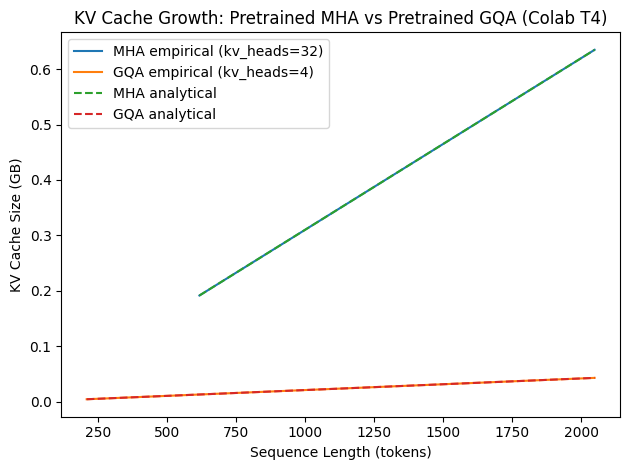


Final KV empirical:
  MHA: 0.634766 GB
  GQA: 0.042969 GB
  Reduction factor (MHA/GQA): 14.77x
  Expected ~ heads/kv_heads ratio: 8.00x (if head_dim/layers are similar)


In [ ]:
MHA_MODEL_ID = "openlm-research/open_llama_3b"
GQA_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

run_cfg = RunCfg(total_tokens=2048, measure_every=128)

# ---- Run MHA ----
print("Loading MHA model:", MHA_MODEL_ID)
tok_mha, model_mha = load_model_and_tokenizer(MHA_MODEL_ID, dtype=torch.float16)
print("Running KV growth (MHA)...")
res_mha = run_kv_growth_pretrained(model_mha, tok_mha, run_cfg)

# free GPU memory before loading second model
del model_mha
torch.cuda.empty_cache()

# ---- Run GQA ----
print("\nLoading GQA model:", GQA_MODEL_ID)
tok_gqa, model_gqa = load_model_and_tokenizer(GQA_MODEL_ID, dtype=torch.float16)
print("Running KV growth (GQA)...")
res_gqa = run_kv_growth_pretrained(model_gqa, tok_gqa, run_cfg)

del model_gqa
torch.cuda.empty_cache()

# ---- Print summaries ----
def describe(res, name):
    meta = res["meta"]
    print(f"\n=== {name} ===")
    print("layers:", meta["num_layers"], "heads:", meta["num_heads"], "kv_heads:", meta["num_kv_heads"],
          "hidden:", meta["hidden_size"], "head_dim:", meta["head_dim"], "dtype:", meta["dtype"], "max_pos:", meta["max_pos"])
    print("Final seq_len:", res["seq_len"][-1])
    print("Final KV empirical (GB):", f"{res['kv_gb_empirical'][-1]:.6f}")
    print("Final KV analytical actual (GB):", f"{res['kv_gb_analytical_actual'][-1]:.6f}")
    print("Final KV analytical MHA baseline (GB):", f"{res['kv_gb_analytical_mha'][-1]:.6f}")

describe(res_mha, "MHA model")
describe(res_gqa, "GQA model")

# ---- Plot KV cache growth ----
plt.figure()
plt.plot(res_mha["seq_len"], res_mha["kv_gb_empirical"], label=f"MHA empirical (kv_heads={res_mha['meta']['num_kv_heads']})")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_empirical"], label=f"GQA empirical (kv_heads={res_gqa['meta']['num_kv_heads']})")

plt.plot(res_mha["seq_len"], res_mha["kv_gb_analytical_actual"], linestyle="--", label="MHA analytical")
plt.plot(res_gqa["seq_len"], res_gqa["kv_gb_analytical_actual"], linestyle="--", label="GQA analytical")

plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV Cache Size (GB)")
plt.title("KV Cache Growth: Pretrained MHA vs Pretrained GQA (Colab T4)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Report reduction factor at final length ----
final_mha = res_mha["kv_gb_empirical"][-1]
final_gqa = res_gqa["kv_gb_empirical"][-1]
print("\nFinal KV empirical:")
print("  MHA:", f"{final_mha:.6f}", "GB")
print("  GQA:", f"{final_gqa:.6f}", "GB")
print("  Reduction factor (MHA/GQA):", f"{final_mha / max(final_gqa, 1e-12):.2f}x")
print("  Expected ~ heads/kv_heads ratio:",
      f"{res_mha['meta']['num_heads'] / res_gqa['meta']['num_kv_heads']:.2f}x (if head_dim/layers are similar)")

# 7. Needle in a Haystack Test for Pretrained Models

## Install + Imports

In [ ]:
!pip -q install transformers accelerate matplotlib sentencepiece

In [ ]:
import math, random, time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

## KV sizing + robust cache utilities

In [ ]:
DTYPE_BYTES = {
    torch.float32: 4,
    torch.float16: 2,
    torch.bfloat16: 2,
    torch.int8: 1,
}

def bytes_to_gb(nbytes: int) -> float:
    return nbytes / (1024**3)

def sizeof_past_key_values(past_key_values) -> int:
    """Empirical bytes in cache (legacy tuples or Cache objects; tolerates None)."""
    if past_key_values is None:
        return 0
    if hasattr(past_key_values, "to_legacy_cache"):
        past_key_values = past_key_values.to_legacy_cache()

    total = 0
    for layer_kv in past_key_values:
        if layer_kv is None:
            continue
        if isinstance(layer_kv, (tuple, list)):
            for t in layer_kv:
                if t is None:
                    continue
                total += t.numel() * t.element_size()
        else:
            t = layer_kv
            if t is not None and hasattr(t, "numel"):
                total += t.numel() * t.element_size()
    return total

def cache_to_legacy(past):
    if past is None:
        return None
    if hasattr(past, "to_legacy_cache"):
        return past.to_legacy_cache()
    return past

def infer_model_meta(model) -> Dict:
    cfg = model.config
    num_layers = getattr(cfg, "num_hidden_layers")
    num_heads = getattr(cfg, "num_attention_heads")
    num_kv_heads = getattr(cfg, "num_key_value_heads", num_heads)
    hidden = getattr(cfg, "hidden_size")
    head_dim = hidden // num_heads
    max_pos = getattr(cfg, "max_position_embeddings", None)
    dtype = next(model.parameters()).dtype
    device = next(model.parameters()).device
    return dict(
        num_layers=num_layers, num_heads=num_heads, num_kv_heads=num_kv_heads,
        hidden=hidden, head_dim=head_dim, max_pos=max_pos,
        dtype=str(dtype), device=str(device), vocab_size=getattr(cfg, "vocab_size"),
    )

## Load model helper

In [ ]:
def load_model_and_tokenizer(model_id: str, dtype=torch.float16):
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",  # consistent cache format for experiments
    ).eval()
    return tok, model

## Needle prompt builder (token-budgeted)

In [ ]:
@dataclass
class NeedleCfg:
    total_context_tokens: int = 1800     # prompt length budget (leave room for generation)
    max_new_tokens: int = 32
    depth_fracs: Tuple[float, ...] = (0.1, 0.3, 0.5, 0.7, 0.9)
    trials_per_depth: int = 3
    seed: int = 123

    # Needle content
    secret_key: str = "ZXCV-1299"
    needle_sentence: str = "IMPORTANT: The meeting secret code is ZXCV-1299. Remember this exactly."

    # Query appended at end
    question: str = "Question: What is the meeting secret code? Answer with ONLY the code."


def build_needle_prompt_token_budgeted(tokenizer, needle_sentence: str, question: str,
                                       depth_frac: float,
                                       max_prompt_tokens: int,
                                       seed: int = 123) -> str:
    """
    Builds a prompt whose tokenized length <= max_prompt_tokens.
    Inserts needle at approx depth_frac of the prompt tokens.
    """
    random.seed(seed)

    pre = "You are given meeting notes. One line contains a secret code. You MUST remember it.\n\n"
    post = "\n\n" + question + "\nAnswer:"

    hay_sentence = "Meeting notes: agenda, updates, blockers, timelines, action items.\n"
    hay_chunk = hay_sentence * 8

    tok_pre = len(tokenizer(pre, add_special_tokens=False)["input_ids"])
    tok_post = len(tokenizer(post, add_special_tokens=False)["input_ids"])
    tok_needle = len(tokenizer(needle_sentence + "\n", add_special_tokens=False)["input_ids"])

    budget_for_hay = max_prompt_tokens - (tok_pre + tok_post + tok_needle)
    if budget_for_hay < 200:
        raise ValueError("Not enough prompt budget. Reduce max_new_tokens or increase max_pos model.")

    needle_pos = int(budget_for_hay * depth_frac)

    def fill_to_token_count(target_tokens: int) -> str:
        s = ""
        while True:
            cand = s + hay_chunk
            n = len(tokenizer(cand, add_special_tokens=False)["input_ids"])
            if n > target_tokens:
                break
            s = cand
        return s

    hay_before = fill_to_token_count(needle_pos)
    used_before = len(tokenizer(hay_before, add_special_tokens=False)["input_ids"])
    hay_after = fill_to_token_count(budget_for_hay - used_before)

    prompt = pre + hay_before + needle_sentence + "\n" + hay_after + post

    # Final hard trim (guarantee)
    ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    ids = ids[:max_prompt_tokens]
    return tokenizer.decode(ids)


def needle_present_after_tokenization(tokenizer, prompt: str, secret_key: str) -> bool:
    ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    text = tokenizer.decode(ids)
    return secret_key in text

## Baseline Needle test (no KV compression)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

@torch.no_grad()
def generate_answer(model, tokenizer, prompt: str, max_new_tokens: int) -> str:
    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0], skip_special_tokens=True)

def score_answer(answer_text: str, secret_key: str) -> int:
    return int(secret_key in answer_text)

def run_needle_sweep_baseline(model_id: str,
                              depth_fracs=(0.1,0.3,0.5,0.7,0.9),
                              trials_per_depth=3,
                              max_new_tokens=32,
                              seed=123,
                              dtype=torch.float16):
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    ).eval()

    cfg = model.config
    max_pos = getattr(cfg, "max_position_embeddings", 2048)

    # prompt token budget
    safety = 32
    max_prompt_tokens = max_pos - max_new_tokens - safety

    secret_key = "ZXCV-1299"
    needle_sentence = f"IMPORTANT: The meeting secret code is {secret_key}. Remember this exactly."
    question = "Question: What is the meeting secret code? Answer with ONLY the code."

    print("\nModel:", model_id, "max_pos:", max_pos, "max_prompt_tokens:", max_prompt_tokens)

    results = []
    for d in depth_fracs:
        hits = 0
        for t in range(trials_per_depth):
            prompt = build_needle_prompt_token_budgeted(
                tok, needle_sentence, question, d,
                max_prompt_tokens=max_prompt_tokens,
                seed=seed + t
            )

            # sanity check
            if not needle_present_after_tokenization(tok, prompt, secret_key):
                print(f"[WARN] needle missing after truncation at depth={d:.2f} trial={t}")
                continue

            ans = generate_answer(model, tok, prompt, max_new_tokens=max_new_tokens)
            hits += score_answer(ans, secret_key)

        acc = hits / trials_per_depth
        results.append((d, acc))
        print(f"depth={d:.2f}  acc={acc:.2f}")

    del model
    torch.cuda.empty_cache()
    return results

## Simulated KV-cache compression (int8) and Needle test

In [ ]:
def split_layer_kv(layer_kv):
    """
    Returns (k, v, extras_tuple)
    layer_kv can be (k,v) or (k,v,extra1,...) etc.
    """
    if not isinstance(layer_kv, (tuple, list)):
        raise ValueError("Unexpected layer_kv format")
    if len(layer_kv) < 2:
        raise ValueError("layer_kv has <2 elements")
    k, v = layer_kv[0], layer_kv[1]
    extras = tuple(layer_kv[2:]) if len(layer_kv) > 2 else tuple()
    return k, v, extras

def quantize_int8_per_tensor(x: torch.Tensor):
    xf = x.detach().float()
    maxv = xf.abs().max().item()
    if maxv == 0.0:
        scale = 1.0
        q = torch.zeros_like(xf, dtype=torch.int8)
        return q, scale
    scale = maxv / 127.0
    q = torch.clamp((xf / scale).round(), -127, 127).to(torch.int8)
    return q, float(scale)

def dequantize_int8(q: torch.Tensor, scale: float, dtype: torch.dtype, device: torch.device):
    return (q.float().to(device) * scale).to(dtype)

def compress_past_int8(past, store_device="cpu"):
    """
    Accepts past_key_values in legacy format (tuple of layers).
    Compresses K and V only; preserves any extra entries.
    """
    past = cache_to_legacy(past)
    compressed = []
    for layer_kv in past:
        k, v, extras = split_layer_kv(layer_kv)
        k_q, k_s = quantize_int8_per_tensor(k)
        v_q, v_s = quantize_int8_per_tensor(v)

        if store_device == "cpu":
            k_q = k_q.cpu()
            v_q = v_q.cpu()

        compressed.append({
            "k_q": k_q, "k_s": k_s, "k_shape": tuple(k.shape),
            "v_q": v_q, "v_s": v_s, "v_shape": tuple(v.shape),
            "extras": extras,  # kept as-is (usually small/none)
        })
    return compressed

def decompress_past_int8(compressed, dtype: torch.dtype, device: torch.device):
    """
    Reconstruct legacy past_key_values: tuple of layer tuples.
    """
    layers = []
    for layer in compressed:
        k = dequantize_int8(layer["k_q"], layer["k_s"], dtype=dtype, device=device).view(layer["k_shape"])
        v = dequantize_int8(layer["v_q"], layer["v_s"], dtype=dtype, device=device).view(layer["v_shape"])
        if layer["extras"]:
            layers.append((k, v, *layer["extras"]))
        else:
            layers.append((k, v))
    return tuple(layers)

def compressed_kv_bytes_int8(compressed) -> int:
    total = 0
    for layer in compressed:
        total += layer["k_q"].numel() * 1
        total += layer["v_q"].numel() * 1
        total += 2 * 4  # k_s, v_s float32
        # extras are ignored in this estimate (usually none)
    return total

## Needle sweep with KV compression + plot accuracy vs depth

In [ ]:
def needle_sweep_kv_int8(model_id: str, cfg: NeedleCfg, dtype=torch.float16, store_device="cpu"):
    tok, model = load_model_and_tokenizer(model_id, dtype=dtype)
    meta = infer_model_meta(model)
    print("Model:", model_id)
    print("Meta:", meta)

    results = []
    kv_gb_estimates = []

    random.seed(cfg.seed)

    for d in cfg.depth_fracs:
        hits = 0
        gb_last = None
        for t in range(cfg.trials_per_depth):
            prompt = build_needle_prompt(tok, cfg, d)
            ans, gb_est = generate_answer_with_kv_int8(model, tok, prompt, cfg.max_new_tokens, store_device=store_device)
            hits += score_answer(ans, cfg.secret_key)
            gb_last = gb_est
        acc = hits / cfg.trials_per_depth
        results.append((d, acc))
        kv_gb_estimates.append(gb_last)

        print(f"depth={d:.2f}  acc={acc:.2f}  (int8 KV est ~ {gb_last:.4f} GB)")

    del model
    torch.cuda.empty_cache()
    return meta, results, kv_gb_estimates

## Run everything for both models (baseline + int8 KV) and plot

In [ ]:
MHA_MODEL_ID = "openlm-research/open_llama_3b"
GQA_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

cfg = NeedleCfg(
    total_context_tokens=1800,  # keep <= ~1900 for max_pos=2048 + generation
    max_new_tokens=24,
    depth_fracs=(0.1, 0.3, 0.5, 0.7, 0.9),
    trials_per_depth=3,
    seed=123,
)

print("\n=== BASELINE (no KV compression) ===")
mha_meta, mha_base = needle_sweep_baseline(MHA_MODEL_ID, cfg)
gqa_meta, gqa_base = needle_sweep_baseline(GQA_MODEL_ID, cfg)

print("\n=== INT8 KV (simulated compression) ===")
mha_meta2, mha_int8, mha_int8_kvgb = needle_sweep_kv_int8(MHA_MODEL_ID, cfg, store_device="cpu")
gqa_meta2, gqa_int8, gqa_int8_kvgb = needle_sweep_kv_int8(GQA_MODEL_ID, cfg, store_device="cpu")

def unpack(res):
    xs = [d for d, a in res]
    ys = [a for d, a in res]
    return xs, ys

plt.figure()
x, y = unpack(mha_base)
plt.plot(x, y, marker="o", label="MHA baseline")

x, y = unpack(mha_int8)
plt.plot(x, y, marker="o", label="MHA + int8-KV (sim)")

x, y = unpack(gqa_base)
plt.plot(x, y, marker="o", label="GQA baseline")

x, y = unpack(gqa_int8)
plt.plot(x, y, marker="o", label="GQA + int8-KV (sim)")

plt.xlabel("Needle depth (fraction of context)")
plt.ylabel("Accuracy (retrieved code)")
plt.title("Needle-in-a-Haystack: Baseline vs Simulated KV Compression")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("\n(Informational) Last-step estimated int8 KV sizes:")
print("  MHA int8 KV est ~", mha_int8_kvgb[-1], "GB")
print("  GQA int8 KV est ~", gqa_int8_kvgb[-1], "GB")


=== BASELINE (no KV compression) ===


Loading weights:   0%|          | 0/237 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2400 > 2048). Running this sequence through the model will result in indexing errors


Model: openlm-research/open_llama_3b
Meta: {'num_layers': 26, 'num_heads': 32, 'num_kv_heads': 32, 'hidden': 3200, 'head_dim': 100, 'max_pos': 2048, 'dtype': 'torch.float16', 'device': 'cuda:0', 'vocab_size': 32000}
depth=0.10  acc=0.00
depth=0.30  acc=0.00
depth=0.50  acc=0.00
depth=0.70  acc=0.00
depth=0.90  acc=0.00


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2052 > 2048). Running this sequence through the model will result in indexing errors


Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Meta: {'num_layers': 22, 'num_heads': 32, 'num_kv_heads': 4, 'hidden': 2048, 'head_dim': 64, 'max_pos': 2048, 'dtype': 'torch.float16', 'device': 'cuda:0', 'vocab_size': 32000}


OutOfMemoryError: CUDA out of memory. Tried to allocate 190.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 25.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.30 GiB is allocated by PyTorch, and 111.75 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)